In [1]:
import re
import os
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.path import Path
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as colors


In [2]:
simulation_name = "2D"

In [3]:
htcfilename = simulation_name+".htc"
nextLineCoordinates = False
xinj, yinj, xprod, yprod = [], [], [], []
lines = open(htcfilename,"r").readlines()
for line in lines:
    if(line.startswith("domain")):
        line = line.replace(","," ")
        tks = re.split(r'[ ,]+', line)
        print(tks)
        LX, NX, LY, NY, LZ, NZ = float(tks[2]), int(tks[3]), float(tks[4]), int(tks[5]), float(tks[6]), int(tks[7])
        print(LX,NX,LY,NY)
    
    if(nextLineCoordinates):
        tokens = re.split(r'[ ,]+', line)
        #print(tokens[2],tokens[3],tokens[4])
        if(inj):
            xinj.append(float(tokens[4]))
            yinj.append(float(tokens[5]))
        elif(prod):
            xprod.append(float(tokens[4]))
            yprod.append(float(tokens[5]))
    nextLineCoordinates = False
    inj = False
    prod = False
    if(line.startswith("zone")):
        if("prod" in line or "inj" in line):
            # we have a prod or inj
            nextLineCoordinates = True
            if("prod" in line):
                prod = True
                inj = False
            else:
                inj = True
                prod = False

DX = LX/NX
DY = LY/NY
DZ = LZ/NZ
print(DX,DY,DZ,LX,LY,LZ)
xgrid = np.linspace(DX/2,LX-DX/2,NX)
ygrid = np.linspace(DY/2,LY-DY/2,NY)

['domain', '=', '400', '80', '300', '60', '12', '1\n']
400.0 80 300.0 60
5.0 5.0 12.0 400.0 300.0 12.0


In [4]:
from hytecio.core import HytecSimulation
simu: HytecSimulation = HytecSimulation(simulation_name, root='')
simu.read_hytec_results()

Nfluxsamples = simu.handlers.results.grid_res_data.shape[1]
timeSim = simu.handlers.results.get_sample_times_from_grid_res()


In [5]:
vars = simu.handlers.results.grid_res_columns
print(vars)

['timestep', 'Zones', 'Uraninite []', 'Calcite []', 'Goethite []', 'Kaolinite []', 'Beidellite-Mg-Fe []', 'Cristobalite(alpha) []', 'pH []', 'Eh [Volt]', 'head [m]', 'aqueous{SO4[2-]} [mol/kg]', 'aqueous{Ca[2+]} [mol/kg]', 'aqueous{Mg[2+]} [mol/kg]', 'aqueous{Na[+]} [mol/kg]', 'aqueous{Cl[-]} [mol/kg]', 'aqueous{UO2[2+]} [mol/kg]', 'aqueous{Fe[2+]} [mol/kg]', 'aqueous{Al[3+]} [mol/kg]', 'pore-volume-replacement []', 'rate{Uraninite} [molal/s]', 'rate{Goethite} [molal/s]', 'rate{Beidellite-Mg-Fe} [molal/s]', 'x-distance', 'y-distance']


In [6]:
def axplot(ax,xgrid,ygrid,var, fancyvar,cmin = 0, cmax=None):
    if(cmax is None):
        cmax = np.max(var)
    pcm = ax.pcolormesh(xgrid,ygrid,var.T,vmin=cmin,vmax=cmax)
    ax.set_xlabel('X-axis (m)')
    ax.set_ylabel('Y-axis (m)')
    ax.set_title(fancyvar)
    ax.set_xlim(0,LX)
    ax.set_ylim(0,LY)
    ax.scatter(xinj,yinj,color="red",s=3)
    ax.scatter(xprod,yprod,color="white",s=3)
    plt.colorbar(pcm,ax=ax,label=fancyvar)

In [7]:
pH = simu.handlers.results.extract_field_from_grid_res("pH []", nx=NX, ny = NY, nz=NZ)   
Sulf = simu.handlers.results.extract_field_from_grid_res('aqueous{SO4[2-]} [mol/kg]', nx=NX, ny = NY, nz=NZ)
UO2 = simu.handlers.results.extract_field_from_grid_res('Uraninite []', nx=NX, ny = NY, nz=NZ)

os.chdir(simulation_name)
FOLDER = "2D_figs"
if(FOLDER not in os.listdir()):
    os.mkdir(FOLDER)
os.chdir('..')

for sam in range(Nfluxsamples):
    fig, axes = plt.subplots(1,3,figsize=(18,6))
    axs = axes.flatten()

    axplot(axs[0],xgrid,ygrid,pH[:,:,0,sam],"pH",cmin = 1, cmax = 8) #Ph
    axplot(axs[1],xgrid,ygrid,Sulf[:,:,0,sam],"Sulfates") # #Sulfate
    axplot(axs[2],xgrid,ygrid,1-UO2[:,:,0,sam]/UO2[:,:,0,0],"Uranium dissolution",cmax = 1) 

    fig.suptitle(f"Distributions after {timeSim[sam]:.2f} years")
    fig.savefig(f"{simulation_name}/{FOLDER}/dist_{sam}.png")
    fig.clf()


/tmp/ipykernel_24716/3144984753.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1,3,figsize=(18,6))


<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

...

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

ON VA REGARDER LES FLUX MAINTENANT

In [8]:
Nvarflux = len(simu.handlers.results.flux_res_columns)
print("Nvarflux = ",Nvarflux)
fvar = simu.handlers.results.flux_res_columns
print(fvar)
Nwells = len(simu.handlers.results.flux_res_names)
print("Nwells = ", Nwells)
wells = simu.handlers.results.cumflux_res_names
fdata = simu.handlers.results.flux_res_data
cumfdata = simu.handlers.results.cumflux_res_data
Nfluxsamples = simu.handlers.results.flux_res_data.shape[1]
ftimeSim = fdata[0,:,0]
ftimeSim[0] = 0

Nvarflux =  12
['Time', 'aqueous{SO4[2-]} [mol/s]', 'aqueous{Ca[2+]} [mol/s]', 'aqueous{Mg[2+]} [mol/s]', 'aqueous{Na[+]} [mol/s]', 'aqueous{Cl[-]} [mol/s]', 'aqueous{UO2[2+]} [mol/s]', 'aqueous{Fe[2+]} [mol/s]', 'H[+] [mol/s]', 'H2SO4(aq) [mol/s]', 'HSO4[-] [mol/s]', 'water [m3/s]']
Nwells =  31


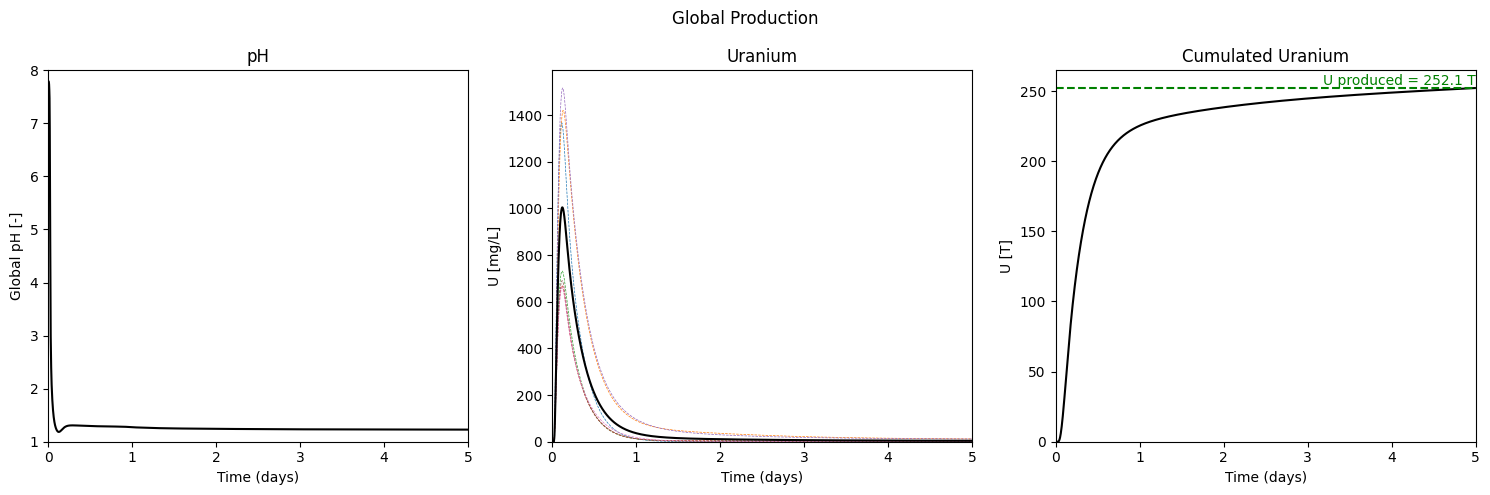

In [9]:
#Global pH
globalPH = np.zeros(Nfluxsamples)
flux = np.zeros(Nfluxsamples)
fluxW = np.zeros(Nfluxsamples)
fluxU = np.zeros(Nfluxsamples)
cumU = np.zeros(Nfluxsamples)
act_coeff = 0.7
idvar = -1
water_id = -1
timeSim = fdata[0,:,0]
for v in range(Nvarflux):
    if(fvar[v]=='H[+] [mol/s]'):
        hvar = v
    if(fvar[v] == 'water [m3/s]'):
        water_id = v
    if(fvar[v] == "aqueous{UO2[2+]} [mol/s]"):
        u_id = v
fig, axes = plt.subplots(1,3,figsize=(15,5))
axs = axes.flatten()
for prod in range(Nwells):
    if('prod' in wells[prod]):
        flux = flux + fdata[hvar,:,prod]
        fluxW = fluxW + fdata[water_id,:,prod]
        fluxU = fluxU + fdata[u_id,:,prod]
        cumU = cumU + cumfdata[u_id,:,prod]
        axs[1].plot(timeSim,abs(238000*fdata[u_id,:,prod]/fdata[water_id,:,prod]/1000),linestyle="dashed",linewidth=0.5)
globalPH = -np.log10(act_coeff*abs(flux/fluxW/1000))
globalU = abs(fluxU*238000/fluxW/1000)

axs[0].plot(timeSim,globalPH,color='black')
axs[0].set_xlabel('Time (days)')
axs[0].set_ylabel('Global pH [-]')
axs[0].set_ylim(1,8)
axs[0].set_xlim(0,5)
axs[0].set_title("pH")

axs[1].plot(timeSim,globalU,color='black')
axs[1].set_xlabel('Time (days)')
axs[1].set_ylabel('U [mg/L]')
axs[1].set_ylim(0)
axs[1].set_xlim(0,5)
axs[1].set_title("Uranium")

axs[2].plot(timeSim,abs(cumU)*0.238/1000,color='black')
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('U [T]')
axs[2].set_ylim(0)
axs[2].set_xlim(0,5)
axs[2].set_title("Cumulated Uranium")
maxprod = np.max(abs(cumU)*0.238/1000)
plt.annotate(f"U produced = {maxprod:.1f} T",xy=(5,maxprod),ha="right",va="bottom",color="green")
plt.axhline(maxprod,color="green",linestyle="dashed")

fig.suptitle("Global Production")
fig.tight_layout()
fig.savefig(f"{simulation_name}/Production.png")

calcul d'acidité injecté / récupérée

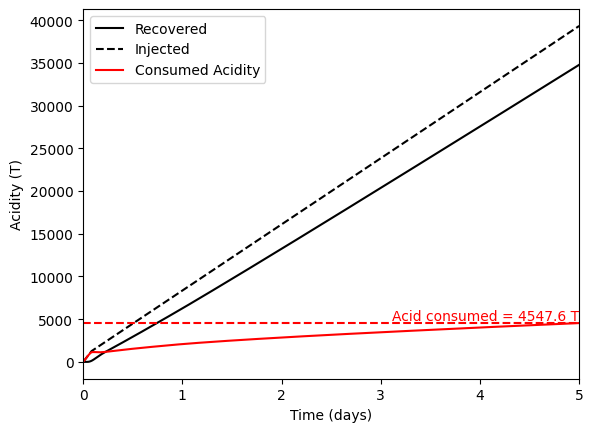

In [10]:
Acid_recovered = np.zeros(Nfluxsamples)
Acid_injected = np.zeros(Nfluxsamples)
varname = ['H[+] [mol/s]','HSO4[-] [mol/s]','H2SO4(aq) [mol/s]']
mH = 1
mSulf = 32+4*16
coefs = [mH,mH+mSulf,2*(2*mH+mSulf)]
idvars = [] #-np.ones(len(varname))
for v in range(len(varname)):   
    for vv in range(Nvarflux):
        if(fvar[vv]==varname[v]):
            idvars.append(round(int(vv)))

for prod in range(Nwells):
    if('prod' in wells[prod]):
        for v in range(len(varname)):                       
            Acid_recovered = Acid_recovered + coefs[v]*cumfdata[idvars[v],:,prod]/1e6 #tonne
    if('inj' in wells[prod]):
        for v in range(len(varname)):
            Acid_injected = Acid_injected + coefs[v]*cumfdata[idvars[v],:,prod]/1e6 #tonn


plt.plot(timeSim,abs(Acid_recovered),color='black',label="Recovered")
plt.plot(timeSim,abs(Acid_injected),color='black',linestyle="dashed",label="Injected")

consumed_ac = abs(Acid_injected)-abs(Acid_recovered)
ac_max = np.nanmax(consumed_ac)
plt.plot(timeSim,consumed_ac,color="red",label="Consumed Acidity")
plt.annotate(f"Acid consumed = {ac_max:.1f} T",xy=(5,ac_max),ha="right",va="bottom",color="red")
plt.axhline(ac_max,color="red",linestyle="dashed")
plt.xlabel('Time (days)')
plt.ylabel('Acidity (T)')
plt.xlim(0,5)
plt.legend()
plt.savefig(f"{simulation_name}/Acidity.png")